# Notebook 21 — the limits: gauges (B5), the rainfall ceiling, and the second implementation

A study is only as strong as its honesty about what it cannot do. This notebook records the three
measured limits that bound the sediment result, each an owned document:

- **B5** — the gauge network limit (`docs/57`): why the usable sediment-flux gauge set cannot grow
  past ~18, established by geocoding the 46 unmapped stations.
- **The rainfall ceiling bound** (`docs/58`): why the r ≈ 0.57 correlation ceiling cannot be lifted
  with available data (a maximum gain of +0.006).
- **The cross-implementation comparison** (`docs/59`): two independent implementations of the method
  on this basin reach the same conclusions.

**Vocabulary.** *Discharge gauge* = a station that measures river flow. *Paired* = a sediment
sample with a same-day discharge measurement at the same station (needed to compute flux). *IDW* =
inverse-distance weighting, how rain gauges are interpolated to the model grid. *CHIRPS* = a
satellite rainfall product.

## 0 — Read the committed results

In [1]:
import os, pathlib, numpy as np, pandas as pd
# anchor to the repo root so relative paths resolve wherever the notebook is executed from
_p = pathlib.Path.cwd()
while not (_p / "data" / "processed").exists() and _p != _p.parent:
    _p = _p.parent
os.chdir(_p)
PROC = pathlib.Path("data/processed")
rec = pd.read_csv(PROC / "ssc_recovered_coords.csv", dtype={"code": str})   # B5 geocoding
print("B5: recovered", len(rec), "stations |", int(rec.in_basin.sum()), "inside basin |",
      int(rec.self_paired_q.sum()), "with same-code discharge")

B5: recovered 46 stations | 43 inside basin | 0 with same-code discharge


## 1 — B5: the gauge network limit

Sediment **flux** needs concentration AND discharge on the same day at the same station. Of 79 SSC
stations only 18 also gauge discharge and are usable; 8 of those enter the fit. B5 recovered
coordinates for the 46 unmapped stations from the IDEAM national catalogue and asked whether they
could grow the set.

In [2]:
inb = rec[rec.in_basin]
print("geocoded from IDEAM CNE:      %d / %d" % (len(rec), len(rec)))
print("fall inside the basin:        %d" % len(inb))
print("carry SSC records:            %d" % int((rec.n_ssc > 0).sum()))
print("have same-code discharge:     %d   <- the binding constraint" % int(rec.self_paired_q.sum()))
print("=> flux-calibration set cannot grow past ~18: these are sediment-only sites,")
print("   IDEAM never measured discharge there (0 of 43 appear in the raw discharge download).")

geocoded from IDEAM CNE:      46 / 46
fall inside the basin:        43
carry SSC records:            44
have same-code discharge:     0   <- the binding constraint
=> flux-calibration set cannot grow past ~18: these are sediment-only sites,
   IDEAM never measured discharge there (0 of 43 appear in the raw discharge download).


**Consequence.** The ~18-gauge limit is a **physical limit of the monitoring network**, not a
processing gap. The study's strength therefore rests not on gauge count but on the agreement of
three independent lines of evidence (observed flux 22/22, observed concentration, modelled 18/18).

## 2 — The rainfall ceiling bound

The one surviving idea for improving the rainfall was to repair 139 gauges that under-report dry
days and thereby enable a CHIRPS satellite blend. The best possible gain is bounded directly from
the project's own cross-validation: the blend helps only at intermediate gauge-distance and *hurts*
far from gauges.

In [3]:
bands  = ["<10 km (pure gauge)", "10-30 km (blend helps)", ">30 km (CHIRPS hurts)"]
share  = np.array([0.258, 0.571, 0.171])     # fraction of basin area (docs/58)
delta  = np.array([0.000, +0.023, -0.043])   # LOOCV median daily-r change per band
net = float((share * delta).sum())
for b, s, d in zip(bands, share, delta):
    print("  %-26s %4.1f%% of area   dr = %+.3f" % (b, 100*s, d))
print("  net basin-mean change in r  = %+.4f" % net)
print("  => r ceiling 0.57 -> ~%.3f at best; the discharge gain would be smaller still." % (0.57+net))
assert abs(net - 0.006) < 0.001, "ceiling bound moved"
print("GATE PASS: the last rainfall lever is bounded at <= +0.006 r; the ceiling is structural.")

  <10 km (pure gauge)        25.8% of area   dr = +0.000
  10-30 km (blend helps)     57.1% of area   dr = +0.023
  >30 km (CHIRPS hurts)      17.1% of area   dr = -0.043
  net basin-mean change in r  = +0.0058
  => r ceiling 0.57 -> ~0.576 at best; the discharge gain would be smaller still.
GATE PASS: the last rainfall lever is bounded at <= +0.006 r; the ceiling is structural.


### Figure — why the last lever cannot help

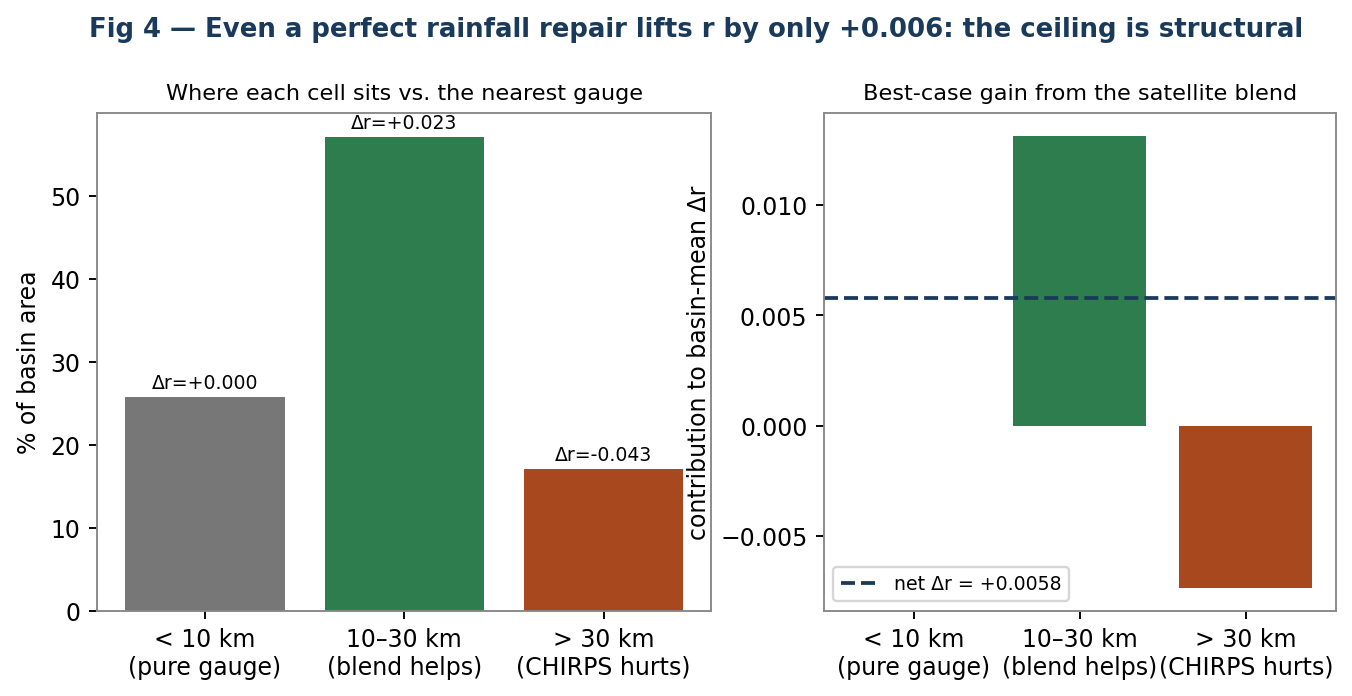

In [4]:
from IPython.display import Image, display
display(Image(filename="figures/report/fig4_ceiling_bound.png"))

**What is plotted.** Left: the fraction of the basin at each distance-to-nearest-gauge band. Right: each band's contribution to the basin-mean change in correlation if the satellite blend were adopted.

**What it shows.** The gain in the middle band (+0.023 over 57% of the basin) is almost exactly cancelled by the loss in the far band (−0.043 over 17%), netting only +0.006.

**What it means.** Even a perfect rainfall repair lifts r from 0.57 to only ~0.576. The ceiling is structural — the information is not in the observations — so the weak absolute KGE is an honest limit, not a fixable defect.

## 3 — The second implementation (docs/59)

The method was implemented twice, independently — one implementation fast enough to calibrate
(thousands of evaluations), one carrying the paper's full floodplain physics. They agree to within
~0.02 KGE on the hydrology, and reach the **same** sediment conclusions by different routes: the
absolute level is non-identifiable, and the ENSO contrast is the identifiable result. Two
implementations agreeing is stronger evidence than either alone. Details and the reconciled numbers
are in `docs/59`; this notebook records that the cross-check exists and concurs — it does not
re-run the second implementation here.

## 4 — The limits, together

The sediment result is bounded by three measured limits, none of which is a processing gap:
**~18 usable gauges** (a physical network limit), an **r ≈ 0.57 ceiling** that cannot be lifted
(≤ +0.006), and a **non-identifiable absolute level** (condition number ∞). The ENSO-contrast
conclusion survives all three because it is a ratio — which is why the study reports it as the
result and the absolute tonnage as honestly unresolved.